 In order to first evaluate the bhdsgan I will use the following procedure:
 1. Sample from a truncated normal distribution with high variance --> gan should perform poorly
 2. Train gan on sampled data
 3. Generate new data and estimate density
 4. Compare actual and estimated density
 5. Sample from a truncated normal distribution with low variance --> gan should perform quite well
 6.Train gan on sampled data
 7. Generate new data and estimate density
 8. Compare actual and estimated density

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from torch import nn
from bhsgan import DiscriminatorBhsSim, GeneratorBhsSim,GeneratorBhsSimNormal
from dataset import SampleDataset
from ipmbhsgan import DiscriminatorIpmSim, GeneratorIpmSim
from trainer import (Trainer, TrainingParams, get_dis_loss_bhs,
                     get_dis_loss_ipm, get_dis_loss_wasserstein,
                     get_gen_loss_bhs, get_gen_loss_ipm,
                     get_gen_loss_wasserstein,get_dis_loss_kl, get_gen_loss_kl, get_dis_loss_rkl, get_gen_loss_rkl,
                     get_dis_loss_gan, get_gen_loss_gan, get_dis_loss_p, get_gen_loss_p)
from utils import get_device, get_noise, init_weights, plot_tensor_images, plot_losses, Positive, save_models_state_dict, load_model_state_dict, RevKlActivation, GanGanActivation
from wgan import DiscriminatorWassersteinSim, GeneratorWassersteinSim, GeneratorWassersteinSimNormal
import random

torch.set_default_dtype(torch.float64)
torch.manual_seed(96)
random.seed(96)

## sample from beta distribution

In [3]:
# sample from beta distributions
mean_1_low = 0
sd_1_low = 1
mean_2_low = 5
sd_2_low = 1
mean_1_high = 0
sd_1_high = 4
mean_2_high = 5
sd_2_high = 4


<AxesSubplot:ylabel='Count'>

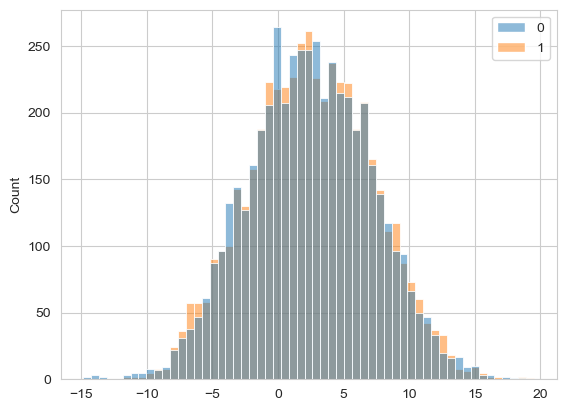

In [4]:
# beta_sample_high = np.random.beta(a_high, b_high, 10000)
normal_sample_1_high = np.random.choice(np.random.normal(mean_1_high, sd_1_high, 10000), 5000)
normal_sample_2_high = np.random.choice(np.random.normal(mean_2_high, sd_2_high, 10000), 5000)
sample_high = np.concatenate([normal_sample_1_high, normal_sample_2_high])
beta_sample_high = np.reshape(sample_high, (5000, 2))
sns.set_style('whitegrid')
sns.histplot(beta_sample_high)

<AxesSubplot:ylabel='Count'>

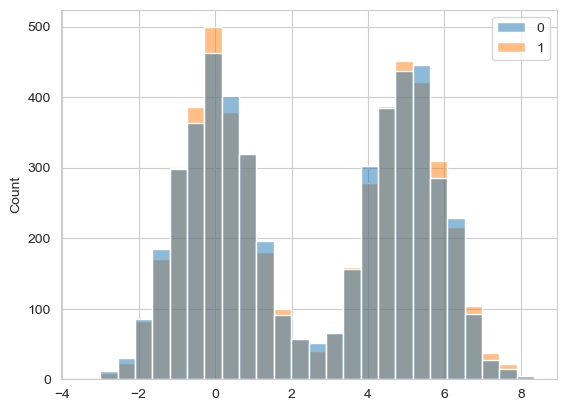

In [5]:
normal_sample_1_low = np.random.choice(np.random.normal(mean_1_low, sd_1_low, 10000), 5000)
normal_sample_2_low = np.random.choice(np.random.normal(mean_2_low, sd_2_low, 10000), 5000)
sample_low = np.concatenate([normal_sample_1_low, normal_sample_2_low])
beta_sample_low = np.reshape(sample_low, (5000, 2))
sns.set_style('whitegrid')
sns.histplot(beta_sample_low)

In [6]:
training_set_high = SampleDataset(beta_sample_high)
training_set_low = SampleDataset(beta_sample_low)

In [7]:
test_noise = get_noise(10000, 2)

## Train BHS GAN

In [8]:
training_params = TrainingParams(lr_dis=0.0002, lr_gen=0.0002, num_epochs=15, num_dis_updates=4, num_gen_updates = 3, beta_1=0.5, batch_size=128)
 
# get device to train on
device = "cpu"

In [9]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)

In [10]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = Positive
generator_high = GeneratorBhsSimNormal()
discriminator_high = DiscriminatorBhsSim(final_activation)
generator_low = GeneratorBhsSimNormal()
discriminator_low = DiscriminatorBhsSim(final_activation)

In [11]:
# init Trainer
trainer_high = Trainer(training_params, generator_high, discriminator_high)
trainer_low = Trainer(training_params, generator_low, discriminator_low)

### Train on high variance samples

In [12]:
# training loop
trained_bhs_high = trainer_high.train_gan(dataloader_high, get_dis_loss_bhs, get_gen_loss_bhs, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.772302	Loss_C : -2.705624	Loss_G : 0.674185	
Total_Time : 4.134329
Loss_C : -2.705624
Loss_G : 0.674185
Loss_C_Mean : -1.886851
Loss_G_Mean : 0.688909

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.718822	Loss_C : -2.599143	Loss_G : 0.436562	
Total_Time : 4.070158
Loss_C : -2.599143
Loss_G : 0.436562
Loss_C_Mean : -2.636575
Loss_G_Mean : 0.616783

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.740698	Loss_C : -4.307743	Loss_G : 0.101164		
Total_Time : 4.086028
Loss_C : -4.307743
Loss_G : 0.101164
Loss_C_Mean : -3.314246
Loss_G_Mean : 0.295827

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.923456	Loss_C : -2.868726	Loss_G : -1.529992	
Total_Time : 4.274800
Loss_C : -2.868726
Loss_G : -1.529992
Loss_C_Mean : -3.2261

In [13]:
generated_data = trained_bhs_high.generator(test_noise)
generated_sample = torch.reshape(generated_data, (1, 20000)).detach().numpy().ravel()

<AxesSubplot:ylabel='Count'>

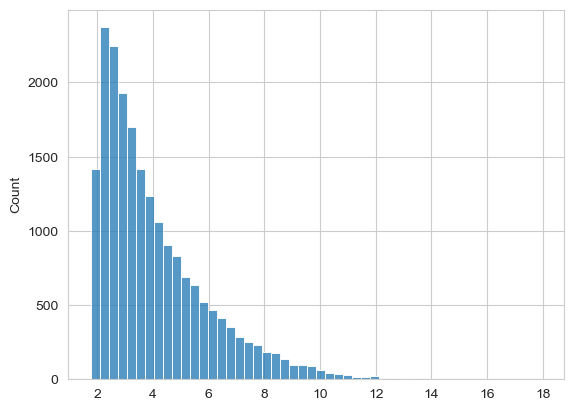

In [14]:
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample, bins=50)

### Train on low variance samples

In [15]:
# training loop
trained_bhs_low = trainer_low.train_gan(dataloader_low, get_dis_loss_bhs, get_gen_loss_bhs, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.962029	Loss_C : -1.266738	Loss_G : 0.572086	
Total_Time : 4.321573
Loss_C : -1.266738
Loss_G : 0.572086
Loss_C_Mean : -0.872578
Loss_G_Mean : 0.595184

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.925429	Loss_C : -1.474439	Loss_G : -0.555593	
Total_Time : 4.285805
Loss_C : -1.474439
Loss_G : -0.555593
Loss_C_Mean : -1.486959
Loss_G_Mean : 0.179600

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.840698	Loss_C : -1.578719	Loss_G : -1.094268	
Total_Time : 4.182094
Loss_C : -1.578719
Loss_G : -1.094268
Loss_C_Mean : -1.452760
Loss_G_Mean : -0.648088

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.813591	Loss_C : -1.763926	Loss_G : -1.338866	
Total_Time : 4.169856
Loss_C : -1.763926
Loss_G : -1.338866
Loss_C_Mean : -1.

In [16]:
generated_data_low = trained_bhs_low.generator(test_noise)
generated_sample_low = torch.reshape(generated_data_low, (1, 20000)).detach().numpy().ravel()

<AxesSubplot:ylabel='Count'>

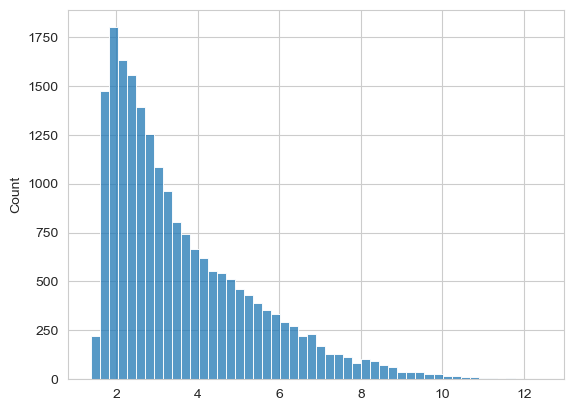

In [17]:
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_low, bins=50)

## Wasserstein GAN 

### High Variance

In [18]:
dataloader_wasserstein_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_high = GeneratorWassersteinSimNormal()
discriminator_wasserstein_high = DiscriminatorWassersteinSim()
trainer_wgan_high = Trainer(training_params, generator_wasserstein_high, discriminator_wasserstein_high)

In [19]:
# training loop
trained_wgan_high = trainer_wgan_high.train_gan(dataloader_wasserstein_high, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 4.704888	Loss_C : 5.524145	Loss_G : 0.071432	
Total_Time : 5.213982
Loss_C : 5.524145
Loss_G : 0.071432
Loss_C_Mean : 5.103733
Loss_G_Mean : 0.099902

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 4.271223	Loss_C : 0.059005	Loss_G : -0.012929	
Total_Time : 4.695764
Loss_C : 0.059005
Loss_G : -0.012929
Loss_C_Mean : 2.412081
Loss_G_Mean : 0.047205

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 4.189501	Loss_C : 0.963701	Loss_G : -0.377593		
Total_Time : 4.639122
Loss_C : 0.963701
Loss_G : -0.377593
Loss_C_Mean : 0.233216
Loss_G_Mean : -0.193591

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 4.461144	Loss_C : -1.564242	Loss_G : -1.119810	
Total_Time : 4.822178
Loss_C : -1.564242
Loss_G : -1.119810
Loss_C_Mean : -0.982032
L

<AxesSubplot:ylabel='Count'>

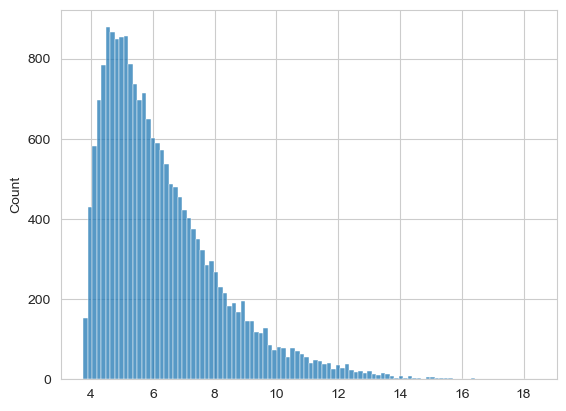

In [20]:
generated_data_wasserstein_high = trained_wgan_high.generator(test_noise)
generated_sample_wasserstein_high = torch.reshape(generated_data_wasserstein_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_high, bins=100)

### Low Variance

In [21]:
dataloader_wasserstein_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
generator_wasserstein_low = GeneratorWassersteinSimNormal()
discriminator_wasserstein_low = DiscriminatorWassersteinSim()
trainer_wgan_low = Trainer(training_params, generator_wasserstein_low, discriminator_wasserstein_low)

In [22]:
# training loop
trained_wgan_low = trainer_wgan_low.train_gan(dataloader_wasserstein_low, get_dis_loss_wasserstein, get_gen_loss_wasserstein, True, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.771746	Loss_C : 1.979588	Loss_G : 0.142951	
Total_Time : 4.138686
Loss_C : 1.979588
Loss_G : 0.142951
Loss_C_Mean : 2.860840
Loss_G_Mean : 0.168006

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 4.059413	Loss_C : -1.105272	Loss_G : -0.094779	
Total_Time : 4.472945
Loss_C : -1.105272
Loss_G : -0.094779
Loss_C_Mean : 0.665619
Loss_G_Mean : -0.036634

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 4.407528	Loss_C : -0.304127	Loss_G : -0.614465	
Total_Time : 4.765580
Loss_C : -0.304127
Loss_G : -0.614465
Loss_C_Mean : -0.527144
Loss_G_Mean : -0.445072

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.775151	Loss_C : -1.140809	Loss_G : -1.078913	
Total_Time : 4.142172
Loss_C : -1.140809
Loss_G : -1.078913
Loss_C_Mean : -0.986

<AxesSubplot:ylabel='Count'>

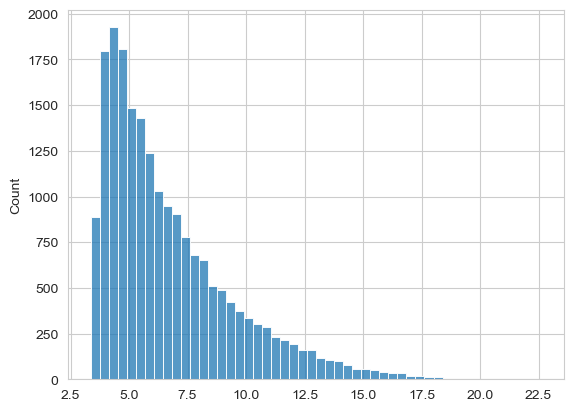

In [28]:
generated_data_wasserstein_low = trained_wgan_low.generator(test_noise)
generated_sample_wasserstein_low = torch.reshape(generated_data_wasserstein_low, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_wasserstein_low, bins=50)

## GAN GAN 

In [29]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Sigmoid
generator_gan_high = GeneratorBhsSimNormal()
discriminator_gan_high = DiscriminatorBhsSim(final_activation)
generator_gan_low = GeneratorBhsSimNormal()
discriminator_gan_low = DiscriminatorBhsSim(final_activation)

In [25]:
### High Variance

In [30]:
trainer_gan_high = Trainer(training_params, generator_gan_high, discriminator_gan_high)

In [31]:
# training loop
trained_gan_high = trainer_gan_high.train_gan(dataloader_high, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.822411	Loss_C : 1.245503	Loss_G : 0.526066	
Total_Time : 4.211583
Loss_C : 1.245503
Loss_G : 0.526066
Loss_C_Mean : 1.314735
Loss_G_Mean : 0.494689

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.719762	Loss_C : 1.097662	Loss_G : 0.596433	
Total_Time : 4.079648
Loss_C : 1.097662
Loss_G : 0.596433
Loss_C_Mean : 1.157980
Loss_G_Mean : 0.560773

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 4.003069	Loss_C : 0.998111	Loss_G : 0.665029	
Total_Time : 4.355310
Loss_C : 0.998111
Loss_G : 0.665029
Loss_C_Mean : 1.051328
Loss_G_Mean : 0.634124

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.668514	Loss_C : 1.013917	Loss_G : 0.721561	
Total_Time : 4.049217
Loss_C : 1.013917
Loss_G : 0.721561
Loss_C_Mean : 0.975622
Loss_G_Mean 

<AxesSubplot:ylabel='Count'>

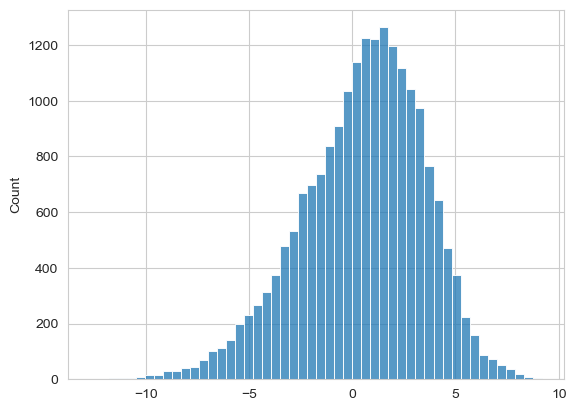

In [32]:
generated_data_gan_high = trained_gan_high.generator(test_noise)
generated_sample_gan_high = torch.reshape(generated_data_gan_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_high, bins=50)

In [ ]:
### Low Variance

In [33]:
trainer_gan_low = Trainer(training_params, generator_gan_low, discriminator_gan_low)

In [34]:
# training loop
trained_gan_low = trainer_gan_low.train_gan(dataloader_low, get_dis_loss_gan, get_gen_loss_gan, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.836443	Loss_C : 1.236233	Loss_G : 0.739322	
Total_Time : 4.210946
Loss_C : 1.236233
Loss_G : 0.739322
Loss_C_Mean : 1.175474
Loss_G_Mean : 0.725384

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 4.010202	Loss_C : 1.248492	Loss_G : 0.753648	
Total_Time : 4.437061
Loss_C : 1.248492
Loss_G : 0.753648
Loss_C_Mean : 1.098893
Loss_G_Mean : 0.756860

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 4.159582	Loss_C : 1.068177	Loss_G : 0.781899	
Total_Time : 4.524536
Loss_C : 1.068177
Loss_G : 0.781899
Loss_C_Mean : 1.058630
Loss_G_Mean : 0.779116

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.692285	Loss_C : 1.015772	Loss_G : 0.735750	
Total_Time : 4.045186
Loss_C : 1.015772
Loss_G : 0.735750
Loss_C_Mean : 1.072035
Loss_G_Mean 

<AxesSubplot:ylabel='Count'>

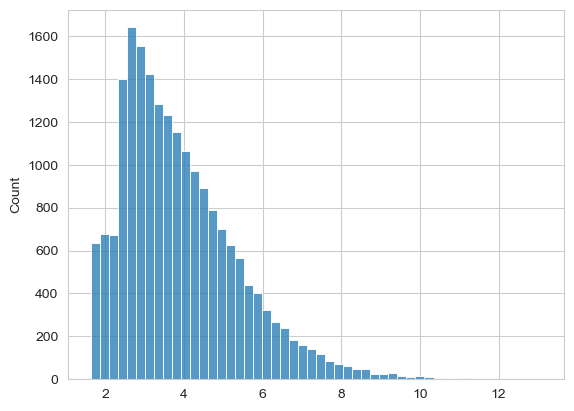

In [35]:
generated_data_gan_low = trained_gan_low.generator(test_noise)
generated_sample_gan_low = torch.reshape(generated_data_gan_low, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_gan_low, bins=50)

## Pearson GAN

In [36]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_pearson_high = GeneratorBhsSimNormal()
discriminator_pearson_high = DiscriminatorBhsSim(final_activation)
generator_pearson_low = GeneratorBhsSimNormal()
discriminator_pearson_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [37]:
trainer_pearson_high = Trainer(training_params, generator_pearson_high, discriminator_pearson_high)

In [38]:
# training loop
trained_pearson_high = trainer_pearson_high.train_gan(dataloader_high, get_dis_loss_p, get_gen_loss_p, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.942419	Loss_C : -0.700718	Loss_G : -0.092930	
Total_Time : 4.366525
Loss_C : -0.700718
Loss_G : -0.092930
Loss_C_Mean : -0.556605
Loss_G_Mean : 0.014784

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 4.053928	Loss_C : -1.870894	Loss_G : -0.100098	
Total_Time : 4.455653
Loss_C : -1.870894
Loss_G : -0.100098
Loss_C_Mean : -1.257749
Loss_G_Mean : -0.069563

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.951577	Loss_C : -1.067661	Loss_G : -0.257608	
Total_Time : 4.302729
Loss_C : -1.067661
Loss_G : -0.257608
Loss_C_Mean : -1.928581
Loss_G_Mean : -0.159591

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 4.095689	Loss_C : -1.870988	Loss_G : -0.412361	
Total_Time : 4.497684
Loss_C : -1.870988
Loss_G : -0.412361
Loss_C_Mean : 

<AxesSubplot:ylabel='Count'>

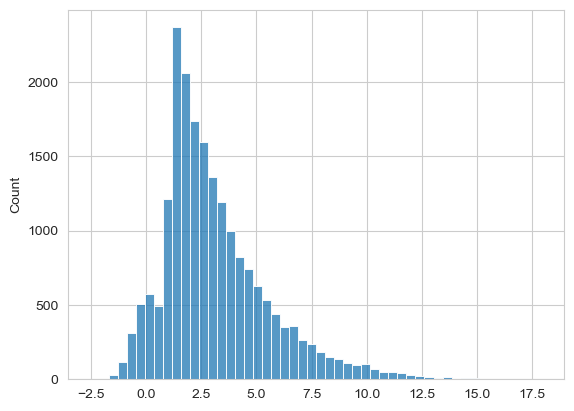

In [39]:
generated_data_pearson_high = trained_pearson_high.generator(test_noise)
generated_sample_pearson_high = torch.reshape(generated_data_pearson_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_pearson_high, bins=50)

In [ ]:
### Low Variance

In [40]:
trainer_pearson_low = Trainer(training_params, generator_pearson_low, discriminator_pearson_low)

In [41]:
# training loop
trained_pearson_low = trainer_pearson_low.train_gan(dataloader_low, get_dis_loss_p, get_gen_loss_p, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.869627	Loss_C : -0.215379	Loss_G : 0.012592	
Total_Time : 4.219898
Loss_C : -0.215379
Loss_G : 0.012592
Loss_C_Mean : -0.122149
Loss_G_Mean : 0.007799

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.915215	Loss_C : -0.667876	Loss_G : 0.001203		
Total_Time : 4.284897
Loss_C : -0.667876
Loss_G : 0.001203
Loss_C_Mean : -0.547610
Loss_G_Mean : 0.008551

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.690658	Loss_C : -0.370808	Loss_G : -0.049027	
Total_Time : 4.045474
Loss_C : -0.370808
Loss_G : -0.049027
Loss_C_Mean : -1.013921
Loss_G_Mean : -0.014615

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.751912	Loss_C : -1.720621	Loss_G : -0.122130	
Total_Time : 4.114030
Loss_C : -1.720621
Loss_G : -0.122130
Loss_C_Mean : -1.5

<AxesSubplot:ylabel='Count'>

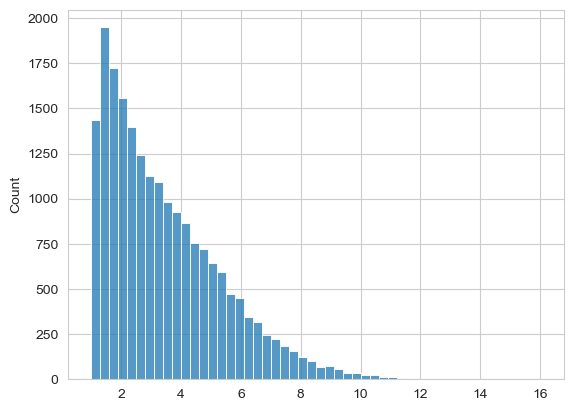

In [42]:
generated_data_pearson_low = trained_pearson_low.generator(test_noise)
generated_sample_pearson_low = torch.reshape(generated_data_pearson_low, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_pearson_low, bins=50)

## KL GAN

In [43]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = nn.Identity
generator_kl_high = GeneratorBhsSimNormal()
discriminator_kl_high = DiscriminatorBhsSim(final_activation)
generator_kl_low = GeneratorBhsSimNormal()
discriminator_kl_low = DiscriminatorBhsSim(final_activation)

In [ ]:
### High Variance

In [44]:
trainer_kl_high = Trainer(training_params, generator_kl_high, discriminator_kl_high)

In [45]:
# training loop
trained_kl_high = trainer_kl_high.train_gan(dataloader_high, get_dis_loss_kl, get_gen_loss_kl, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.804684	Loss_C : -1.188414	Loss_G : -0.476890	
Total_Time : 4.305893
Loss_C : -1.188414
Loss_G : -0.476890
Loss_C_Mean : -0.770093
Loss_G_Mean : -0.424956

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.997741	Loss_C : -2.390593	Loss_G : -0.691157	
Total_Time : 4.402435
Loss_C : -2.390593
Loss_G : -0.691157
Loss_C_Mean : -1.580630
Loss_G_Mean : -0.555165

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.651882	Loss_C : -2.228327	Loss_G : -0.952819	
Total_Time : 4.001284
Loss_C : -2.228327
Loss_G : -0.952819
Loss_C_Mean : -2.237116
Loss_G_Mean : -0.840511

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.959653	Loss_C : -2.736662	Loss_G : -1.647681	
Total_Time : 4.379929
Loss_C : -2.736662
Loss_G : -1.647681
Loss_C_Mean :

<AxesSubplot:ylabel='Count'>

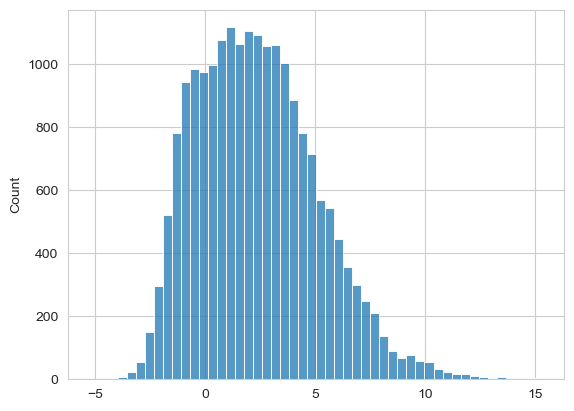

In [46]:
generated_data_kl_high = trained_kl_high.generator(test_noise)
generated_sample_kl_high = torch.reshape(generated_data_kl_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_kl_high, bins=50)

In [47]:
### Low Variance

In [48]:
trainer_kl_low = Trainer(training_params, generator_kl_low, discriminator_kl_low)

In [49]:
# training loop
trained_kl_low = trainer_kl_low.train_gan(dataloader_low, get_dis_loss_kl, get_gen_loss_kl, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.684247	Loss_C : 0.688132	Loss_G : -0.259159	
Total_Time : 4.037012
Loss_C : 0.688132
Loss_G : -0.259159
Loss_C_Mean : 0.870618
Loss_G_Mean : -0.228207

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.649327	Loss_C : 0.008684	Loss_G : -0.325971		
Total_Time : 4.008570
Loss_C : 0.008684
Loss_G : -0.325971
Loss_C_Mean : 0.325616
Loss_G_Mean : -0.294137

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.617043	Loss_C : -0.658075	Loss_G : -0.448510	
Total_Time : 3.981390
Loss_C : -0.658075
Loss_G : -0.448510
Loss_C_Mean : -0.295566
Loss_G_Mean : -0.388923

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.556826	Loss_C : -1.411761	Loss_G : -0.727030	
Total_Time : 3.936123
Loss_C : -1.411761
Loss_G : -0.727030
Loss_C_Mean : -0.8

<AxesSubplot:ylabel='Count'>

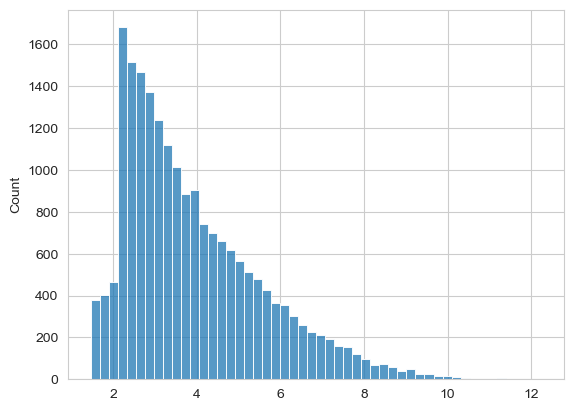

In [50]:
generated_data_kl_low = trained_kl_low.generator(test_noise)
generated_sample_kl_low = torch.reshape(generated_data_kl_low, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_kl_low, bins=50)

## RV KL GAN

In [51]:
# Create the dataloaders
dataloader_high = torch.utils.data.DataLoader(training_set_high, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
dataloader_low = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# initialize nets
final_activation = RevKlActivation
generator_rvkl_high = GeneratorBhsSimNormal()
discriminator_rvkl_high = DiscriminatorBhsSim(final_activation)
generator_rvkl_low = GeneratorBhsSimNormal()
discriminator_rvkl_low = DiscriminatorBhsSim(final_activation)

In [52]:
### High Variance

In [53]:
trainer_rvkl_high = Trainer(training_params, generator_rvkl_high, discriminator_rvkl_high)

In [54]:
# training loop
trained_rvkl_high = trainer_rvkl_high.train_gan(dataloader_high, get_dis_loss_rkl, get_gen_loss_rkl, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.660513	Loss_C : -0.082922	Loss_G : 0.920029	
Total_Time : 4.017982
Loss_C : -0.082922
Loss_G : 0.920029
Loss_C_Mean : 0.059354
Loss_G_Mean : 0.905941

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.591161	Loss_C : -0.598535	Loss_G : 0.991080	
Total_Time : 3.951807
Loss_C : -0.598535
Loss_G : 0.991080
Loss_C_Mean : -0.337658
Loss_G_Mean : 0.951216

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.611870	Loss_C : -0.564236	Loss_G : 1.070165	
Total_Time : 3.961735
Loss_C : -0.564236
Loss_G : 1.070165
Loss_C_Mean : -0.529932
Loss_G_Mean : 1.029575

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.853817	Loss_C : -0.704771	Loss_G : 1.056334	
Total_Time : 4.207952
Loss_C : -0.704771
Loss_G : 1.056334
Loss_C_Mean : -0.651593
L

<AxesSubplot:ylabel='Count'>

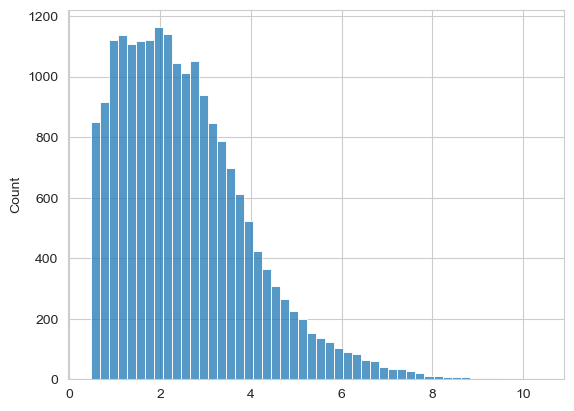

In [55]:
generated_data_rvkl_high = trained_rvkl_high.generator(test_noise)
generated_sample_rvkl_high = torch.reshape(generated_data_rvkl_high, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_rvkl_high, bins=50)

In [56]:
### Low Variance

In [57]:
trainer_rvkl_low = Trainer(training_params, generator_rvkl_low, discriminator_rvkl_low)

In [58]:
# training loop
trained_rvkl_low = trainer_rvkl_low.train_gan(dataloader_low, get_dis_loss_rkl, get_gen_loss_rkl, False, print_intermediate=False)

Epoch 1 start training...
Epoch: 1/15 Total Steps:40och_Run_Time: 3.664986	Loss_C : -0.300739	Loss_G : 0.911336	
Total_Time : 4.013426
Loss_C : -0.300739
Loss_G : 0.911336
Loss_C_Mean : -0.220834
Loss_G_Mean : 0.908080

----------------------------------------------

Epoch 2 start training...
Epoch: 2/15 Total Steps:80och_Run_Time: 3.633856	Loss_C : -0.417715	Loss_G : 0.991187	
Total_Time : 3.997580
Loss_C : -0.417715
Loss_G : 0.991187
Loss_C_Mean : -0.364650
Loss_G_Mean : 0.960360

----------------------------------------------

Epoch 3 start training...
Epoch: 3/15 Total Steps:120ch_Run_Time: 3.628294	Loss_C : -0.576663	Loss_G : 1.114434	
Total_Time : 3.982581
Loss_C : -0.576663
Loss_G : 1.114434
Loss_C_Mean : -0.449084
Loss_G_Mean : 1.043280

----------------------------------------------

Epoch 4 start training...
Epoch: 4/15 Total Steps:160ch_Run_Time: 3.638141	Loss_C : -0.465215	Loss_G : 1.210605	
Total_Time : 3.996397
Loss_C : -0.465215
Loss_G : 1.210605
Loss_C_Mean : -0.527612


<AxesSubplot:ylabel='Count'>

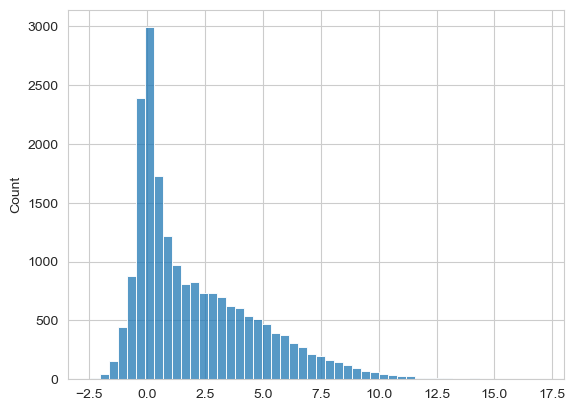

In [59]:
generated_data_rvkl_low = trained_rvkl_low.generator(test_noise)
generated_sample_rvkl_low = torch.reshape(generated_data_rvkl_low, (1, 20000)).detach().numpy().ravel()
# plot resulting density
sns.set_style('whitegrid')
sns.histplot(generated_sample_rvkl_low, bins=50)

## Now I train the IPM Version for the BHS GAN

In [ ]:
# initialize nets
generator_ipm = GeneratorIpmSim()
discriminator_ipm = DiscriminatorIpmSim()

In [ ]:
dataloader_ipm = torch.utils.data.DataLoader(training_set_low, batch_size=training_params.batch_size,
                                         shuffle=True, num_workers=1)
# init Trainer
trainer_ipm_gan = Trainer(training_params, generator_ipm, discriminator_ipm)

In [ ]:
# training loop
trained_ipm_gan = trainer_ipm_gan.train_gan(dataloader_ipm, get_dis_loss_ipm, get_gen_loss_ipm, False)

In [ ]:
generated_data_ipm = trained_ipm_gan.generator(test_noise)
generated_sample_ipm = torch.reshape(generated_data_ipm, (1, 1000)).detach().numpy().ravel()

In [ ]:
# plot resulting density
sns.set_style('whitegrid')
sns.kdeplot(generated_sample_ipm, bw=0.5)

In [ ]:
# plot losses
plt.figure(figsize=(10,5))
plt.title("Generator and Discriminator Loss During Training")
plt.plot(trained_ipm_gan.generator_losses,label="G-Loss")
plt.plot(trained_ipm_gan.discriminator_losses,label="D-Loss")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# check mean and varaince of generated data
np.mean(generated_sample_ipm)

In [ ]:
np.std(generated_sample_ipm)

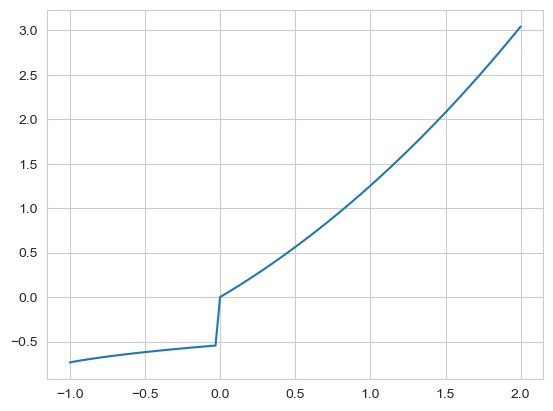

In [68]:
data_points = np.linspace(-1, 2, 100)
def conjugate(points):
    conjugate_1 = 2 * (-1 + np.sqrt(1 + points)) * np.exp(-1 + np.sqrt(1 + points)) 
    conjugate_2 = 2 * (-1 - np.sqrt(1 + points)) * np.exp(-1 - np.sqrt(1 + points)) 
    return np.where(points >= 0, conjugate_1, conjugate_2)
plt.plot(data_points, conjugate(data_points))

C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:2: RuntimeWarning: divide by zero encountered in log
  f_1 = points * np.log(points)**2
C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:2: RuntimeWarning: invalid value encountered in log
  f_1 = points * np.log(points)**2
C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:2: RuntimeWarning: invalid value encountered in multiply
  f_1 = points * np.log(points)**2
C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:3: RuntimeWarning: divide by zero encountered in log
  f_2 = -points * np.log(points)**2
C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:3: RuntimeWarning: invalid value encountered in log
  f_2 = -points * np.log(points)**2
C:\Users\fottneal\AppData\Local\Temp\ipykernel_20700\968695790.py:3: RuntimeWarning: invalid value encountered in multiply
  f_2 = -points * np.log(points)**2


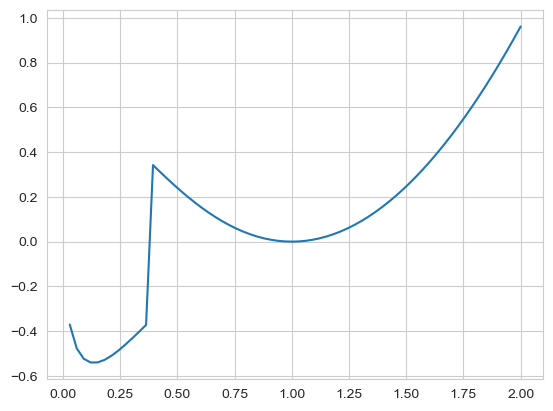

In [62]:
def f(points):
    f_1 = points * np.log(points)**2
    f_2 = -points * np.log(points)**2
    return np.where(points >= np.exp(-1), f_1, f_2)
plt.plot(data_points, f(data_points))

In [69]:
2 * (-1 - np.sqrt(1 + -1)) * np.exp(-1 - np.sqrt(1 + -1))

-0.7357588823428847

In [ ]:
conjugate(data_points)